#  Multi-Turn Chat Message Intent Classification
### Team 1 - Module 7 | NLP Project
**Tools:** SpaCy, Scikit-learn, BERT, ML  
**Dataset:** Custom Large-Scale Intent Dataset   
**Goal:** Classify chat messages into intents: Query, Complaint, Greeting, Farewell, Request, Appreciation, Escalation, Feedback, and more.

---

##  Step 0: Interactive Multi-Turn Conversation Intent Analyzer
### Paste any comment, review, or multi-turn dialogue below and get instant intent analysis!

```python
# ============================================================
#  INTERACTIVE MULTI-TURN CONVERSATION INTENT ANALYZER
# ============================================================
# HOW TO USE:
#   Option A – Single text: Put your comment/review in USER_INPUT
#   Option B – Multi-turn chat: Add multiple messages to CONVERSATION_TURNS
#
# Then run this cell (Shift+Enter) to see the full intent analysis!
# ============================================================

import re
from anthropic import Anthropic

client = Anthropic()

# ──  CONFIGURE YOUR INPUT HERE ────────────────────────────────────────────

# Option A: Single comment or review (set CONVERSATION_TURNS = [] to use this)
USER_INPUT = """
I ordered a laptop last week and it still hasn't arrived. 
The tracking page just says 'in transit' for 5 days straight.
Nobody from support is responding to my emails either.
I really need this for work. This is so frustrating.
"""

# Option B: Multi-turn conversation (leave USER_INPUT = "" to use this)
CONVERSATION_TURNS = [
    # {"turn": 1, "speaker": "User", "message": "Hi! I just got my order but something looks off."},
    # {"turn": 2, "speaker": "User", "message": "The screen has a crack. This is not acceptable!"},
    # {"turn": 3, "speaker": "User", "message": "Can you please arrange a replacement or refund?"},
    # {"turn": 4, "speaker": "User", "message": "Thanks for the help. Really appreciate it. Goodbye!"},
]

# ── END OF CONFIGURATION ─────────────────────────────────────────────────────

INTENT_CATEGORIES = [
    "Query", "Complaint", "Greeting", "Farewell", "Request",
    "Appreciation", "Escalation", "Feedback", "Clarification"
]

def analyze_single_text(text: str) -> dict:
    """Analyze a single comment/review for intent using Claude."""
    system_prompt = """You are an expert NLP intent classification system.
Your job is to analyze text and identify conversation intents.
Always respond in valid JSON only — no preamble, no markdown fences."""

    user_prompt = f"""Analyze the following text for multi-turn conversation intent.

TEXT:
\"\"\"
{text.strip()}
\"\"\"

Identify:
1. Primary intent (choose from: Query, Complaint, Greeting, Farewell, Request, Appreciation, Escalation, Feedback, Clarification)
2. Secondary intents if present
3. Emotional tone (Neutral / Positive / Negative / Mixed)
4. Urgency level (Low / Medium / High)
5. Key intent signals (words/phrases driving the classification)
6. A short explanation of the classification

Return ONLY a JSON object with this exact structure:
{{
  "primary_intent": "...",
  "secondary_intents": ["...", "..."],
  "emotional_tone": "...",
  "urgency": "...",
  "key_signals": ["...", "..."],
  "explanation": "..."
}}"""

    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=600,
        messages=[{"role": "user", "content": user_prompt}],
        system=system_prompt
    )
    raw = response.content[0].text.strip()
    # Strip markdown fences if present
    raw = re.sub(r"^```json\s*|^```\s*|\s*```$", "", raw, flags=re.MULTILINE).strip()
    return json.loads(raw)


def analyze_multi_turn(turns: list) -> dict:
    """Analyze a multi-turn conversation for evolving intent using Claude."""
    system_prompt = """You are an expert NLP intent classification system specializing in multi-turn dialogue.
Analyze each turn and the overall conversation flow.
Always respond in valid JSON only — no preamble, no markdown fences."""

    conversation_text = "\n".join(
        [f"Turn {t['turn']} ({t['speaker']}): {t['message']}" for t in turns]
    )

    user_prompt = f"""Analyze the following multi-turn conversation for intent classification.

CONVERSATION:
{conversation_text}

For each turn, identify its intent. Then provide an overall analysis.

Return ONLY a JSON object with this exact structure:
{{
  "turns": [
    {{
      "turn": 1,
      "message_preview": "...",
      "intent": "...",
      "confidence": "High/Medium/Low",
      "emotional_tone": "Neutral/Positive/Negative/Mixed"
    }}
  ],
  "intent_flow": ["intent1", "intent2", "..."],
  "dominant_intent": "...",
  "conversation_summary": "...",
  "escalation_detected": true/false,
  "overall_tone": "...",
  "recommended_action": "..."
}}"""

    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=1000,
        messages=[{"role": "user", "content": user_prompt}],
        system=system_prompt
    )
    raw = response.content[0].text.strip()
    raw = re.sub(r"^```json\s*|^```\s*|\s*```$", "", raw, flags=re.MULTILINE).strip()
    return json.loads(raw)


import json

# ── RUN ANALYSIS ─────────────────────────────────────────────────────────────

if CONVERSATION_TURNS:
    print(" MULTI-TURN CONVERSATION INTENT ANALYSIS")
    print("=" * 70)
    result = analyze_multi_turn(CONVERSATION_TURNS)

    print(f"{'Turn':<6} {'Message':<40} {'Intent':<18} {'Conf':<8} {'Tone'}")
    print("-" * 70)
    for t in result["turns"]:
        preview = t["message_preview"][:38] + ".." if len(t["message_preview"]) > 38 else t["message_preview"]
        print(f"{t['turn']:<6} {preview:<40} {t['intent']:<18} {t['confidence']:<8} {t['emotional_tone']}")

    print("\n Intent Flow:")
    print(" → ".join([f"T{i+1}:{v}" for i, v in enumerate(result["intent_flow"])]))

    print(f"\n Dominant Intent    : {result['dominant_intent']}")
    print(f"  Overall Tone       : {result['overall_tone']}")
    print(f" Escalation Detected: {'Yes' if result['escalation_detected'] else 'No'}")
    print(f" Summary            : {result['conversation_summary']}")
    print(f" Recommended Action : {result['recommended_action']}")

elif USER_INPUT.strip():
    print(" SINGLE TEXT INTENT ANALYSIS")
    print("=" * 60)
    print(f" Input Preview: {USER_INPUT.strip()[:80]}...")
    print("-" * 60)
    result = analyze_single_text(USER_INPUT)

    print(f" Primary Intent    : {result['primary_intent']}")
    if result["secondary_intents"]:
        print(f" Secondary Intents : {', '.join(result['secondary_intents'])}")
    print(f"  Emotional Tone    : {result['emotional_tone']}")
    print(f" Urgency Level     : {result['urgency']}")
    print(f" Key Signals       : {', '.join(result['key_signals'])}")
    print(f" Explanation       : {result['explanation']}")

else:
    print("  Please set USER_INPUT or populate CONVERSATION_TURNS above, then re-run.")
```

## Step 1: Install & Import Libraries

In [4]:
# Install required libraries
!pip install transformers torch scikit-learn spacy pandas numpy matplotlib seaborn datasets accelerate -q
!python -m spacy download en_core_web_sm -q

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import spacy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader

import re
import string
import random
from collections import Counter


# Load SpaCy
nlp = spacy.load('en_core_web_sm')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(' All libraries loaded successfully!')
print(f' PyTorch version: {torch.__version__}')
print(f' CUDA available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Using device: {device}')

 All libraries loaded successfully!
 PyTorch version: 2.7.1+cpu
 CUDA available: False
 Using device: cpu


##  Step 2: Build Large-Scale Intent Dataset
We create a **massive, diverse dataset** with 9 intent categories and hundreds of varied examples per category.

In [9]:
# ============================================================
# LARGE INTENT DATASET - 9 Categories, 100+ examples each
# ============================================================

intent_data = {
    # ----------------------------------------------------------------
    # 1. QUERY - User asking for information
    # ----------------------------------------------------------------
    'query': [
        "What are the store hours?", "When does the sale end?",
        "Can you tell me the price of this product?", "How do I reset my password?",
        "Where is your nearest branch located?", "What documents are required for registration?",
        "How long does shipping take?", "What is the return policy?",
        "Do you offer student discounts?", "What payment methods do you accept?",
        "Is this item available in blue?", "What size should I order?",
        "Do you have any vegetarian options?", "How many calories does this have?",
        "What is the warranty period?", "Can I track my order online?",
        "Is there parking available?", "What time does the last train leave?",
        "Do you ship internationally?", "What is the minimum order quantity?",
        "How do I cancel my subscription?", "What are the eligibility criteria?",
        "Is the product gluten-free?", "What is your exchange policy?",
        "Can I modify my order after placing it?", "What are the terms and conditions?",
        "Is there a trial period?", "How many users can use one account?",
        "What is the deadline for applications?", "Can I get a receipt for my purchase?",
        "What is the difference between plan A and plan B?", "Are there any hidden charges?",
        "What is the processing time for refunds?", "Is this product FDA approved?",
        "Where can I download the app?", "What OS does this software support?",
        "How do I update my billing information?", "What happens after I submit the form?",
        "Can I use multiple promo codes?", "What is your cancellation policy?",
        "Is there a loyalty program?", "How do I redeem my points?",
        "What is the age limit for this activity?", "Do I need a reservation?",
        "How much does it cost to upgrade?", "Is there a setup fee?",
        "What languages is the app available in?", "How do I contact customer support?",
        "Can I pause my subscription?", "What are the available delivery slots?",
        "How do I add items to my wishlist?", "What is your data privacy policy?",
        "Do you have a physical store?", "Is the discount applied automatically?",
        "What is the checkout process?", "How do I report a technical issue?",
        "Can I get a bulk discount?", "What courses are available for beginners?",
        "Is there a free version available?", "How secure is your payment gateway?",
        "What are your business hours?", "Can I schedule a callback?",
        "How many days in advance do I need to book?", "What is the fuel policy for rentals?",
        "Is travel insurance included?", "What is the baggage allowance?",
        "Do you have halal certified food?", "What is the average delivery time?",
        "Is this drug available over the counter?", "What is the recommended dosage?",
        "Are there any side effects?", "Does this come with a charger?",
        "How do I enable two-factor authentication?", "What is the storage capacity?",
        "How do I export my data?", "Can I use this offline?",
        "What happens if I miss a payment?", "Is there a grace period?",
        "Do you provide invoices?", "What currencies do you support?",
        "How do I apply for a refund?", "What is the status of my ticket?",
        "Can I bring a guest?", "Is there an early bird offer?",
        "What is included in the package?", "Do you offer home delivery?",
        "Can I get a sample before ordering?", "What is the stock level?",
        "How do I verify my account?", "Is the training session recorded?",
        "Are there any prerequisites for this course?", "How long is the certification valid?",
        "What is your response time for queries?", "Is there a chat support option?",
        "Do you support API integration?", "What version is the latest software?",
        "How do I change my email address?", "Is there a mobile app for this?",
        "What is the battery life?", "Does it work on Mac?",
        "Is GST included in the price?", "How do I get my tax invoice?",
        "What is the difference between monthly and annual plans?",
    ],

    # ----------------------------------------------------------------
    # 2. COMPLAINT - User expressing dissatisfaction
    # ----------------------------------------------------------------
    'complaint': [
        "I am very disappointed with the service.", "This product is terrible quality.",
        "My order was completely wrong.", "I have been waiting for 2 weeks and nothing arrived.",
        "The customer support is absolutely useless.", "I was charged twice for the same order.",
        "The app keeps crashing every time I open it.", "Your website is down again.",
        "The food was cold when it arrived.", "I received a damaged product.",
        "No one is responding to my emails.", "I have been on hold for 45 minutes.",
        "The delivery driver was very rude.", "This is not what I ordered at all.",
        "The product stopped working after one day.", "I am extremely frustrated with this experience.",
        "You debited my account without permission.", "The service is way too expensive for what it offers.",
        "The staff was completely unhelpful.", "I never received a confirmation email.",
        "My package was left outside in the rain.", "The item looks nothing like the photos.",
        "This is the third time I'm facing this issue.", "I can't believe how poor your service is.",
        "My subscription was not cancelled as requested.", "You promised a refund two weeks ago.",
        "The quality has gone down significantly.", "I am unhappy with the way my complaint was handled.",
        "Your checkout page has a bug.", "I was given wrong information by your agent.",
        "The product smells bad.", "There was a hair in my food.",
        "I received someone else's order.", "The size does not match what was described.",
        "This is a complete waste of money.", "I have been ignored for days.",
        "Your app shows wrong prices.", "The payment failed but money was deducted.",
        "This is unacceptable service.", "I want to escalate this matter immediately.",
        "My account was hacked and no one is helping.", "You sent me an expired product.",
        "The technician came late and fixed nothing.", "I was not informed about additional charges.",
        "The return process is a nightmare.", "Your call center is impossible to reach.",
        "I'm very upset about this situation.", "This is not the first time you've failed me.",
        "I have screenshots of all the issues.", "I will be leaving a negative review.",
        "This is false advertising.", "The discount was not applied to my order.",
        "The connection keeps dropping.", "Your courier service is unreliable.",
        "I ordered 3 items but only received 1.", "The product is clearly a counterfeit.",
        "I am deeply dissatisfied.", "Nobody takes responsibility here.",
        "The installation was done incorrectly.", "I am still waiting for my invoice.",
        "This experience has been horrible from start to finish.",
        "My complaint has been ignored for a week.", "The food was undercooked and unsafe.",
        "You have been deducting money without my knowledge.",
        "Your product caused damage to my device.", "The battery drains in under an hour.",
        "The product leaked and ruined my bag.", "None of your agents know what they're doing.",
        "I have filed a complaint before and nothing was done.",
        "Your cancellation process is too complicated.", "You ignored my refund request.",
        "The wrong model was delivered.", "My data was deleted without warning.",
        "Your promises are empty and never fulfilled.", "The service went down during an important meeting.",
        "Your product broke within a month.", "No one called me back as promised.",
        "The tracking information is wrong.", "You cancelled my order without telling me.",
        "I am considering switching to a competitor.", "This is completely unacceptable.",
        "I expected much better from a company like yours.",
        "The packaging was terrible and the item was damaged.",
        "Your agent gave me attitude on the call.", "I've been a loyal customer and this is how you treat me.",
        "Your store refused to honor the warranty.", "I want my money back immediately.",
        "The order arrived a month late.", "Your system has too many bugs.",
        "I am fed up with this constant problem.", "My renewal was processed without consent.",
        "You have the worst customer service I've encountered.",
        "The product does not work as advertised.", "I had to fix the issue myself.",
        "Your store manager was dismissive and rude.",
    ],

    # ----------------------------------------------------------------
    # 3. GREETING - User initiating or opening a conversation
    # ----------------------------------------------------------------
    'greeting': [
        "Hello!", "Hi there!", "Hey, good morning!", "Good afternoon!",
        "Good evening, hope you're well.", "Hi, I need some help.",
        "Hey! Is anyone there?", "Greetings!", "Howdy!", "What's up?",
        "Hi, my name is John.", "Hello, I'm a new customer.",
        "Hey, I just signed up!", "Good day to you!", "Hi! Long time no chat.",
        "Hello, is this customer service?", "Hey, can you assist me?",
        "Hi, I'd like to get some information.", "Good morning, team!",
        "Hello there, I have a question.", "Hey! Hope you're having a great day.",
        "Hi, I am reaching out for the first time.", "Good morning! How are you?",
        "Hiya! Quick question for you.", "Hi! Thanks for being available.",
        "Hello, I'm looking for assistance.", "Hey, good to connect with you!",
        "Good afternoon, I need help please.", "Hi, just checking in.",
        "Namaste!", "Salutations!", "Hi, can I speak to someone?",
        "Hello, I am back again.", "Hey, glad I found the chat feature.",
        "Good morning, are you available?", "Hi! I hope I'm in the right place.",
        "Hi, I saw your ad and have questions.", "Hello, I'm an existing customer.",
        "Hey there! Just wanted to say hi.", "Hi! I need urgent help.",
        "Good day! I'm trying to reach support.", "Hello, I was referred by a friend.",
        "Hi agent, are you online?", "Hey, nice to meet you!",
        "Hello, I'm interested in your services.", "Hi there, I'm back!",
        "Good morning sunshine!", "Hello! Starting fresh today.",
        "Hey! I need to talk to someone.", "Hi, hope I'm not bothering you.",
        "Good evening! I need some support.", "Hello, lovely to chat with you.",
        "Hi there, I've been trying to reach you.", "Hey, can you hear me?",
        "Hello, this is my first time here.", "Hey, I just moved and need help setting up.",
        "Hi! Hope all is well on your end.", "Good morning, I would like to inquire.",
        "Greetings from Mumbai!", "Hi, I'm writing in on behalf of my company.",
        "Hello, are you the right person to ask?", "Hey, anyone online?",
        "Hi! Quick one for you.", "Good evening, ready to help?",
        "Hey, I've never done this before.", "Hello and good day!",
        "Hi, lovely to meet you!", "Hey there, reaching out for the first time.",
    ],

    # ----------------------------------------------------------------
    # 4. FAREWELL - User closing the conversation
    # ----------------------------------------------------------------
    'farewell': [
        "Goodbye!", "Thanks, bye!", "That will be all, thank you.",
        "Have a great day!", "See you later!", "Take care!",
        "Thanks for your help, goodbye.", "Bye bye!",
        "I think I'm good now, thanks.", "That answers my question. Cheers!",
        "All sorted, thanks a lot!", "Good night!",
        "Have a nice evening!", "We're done here, thanks.",
        "I appreciate it. Goodbye!", "Alright, signing off now.",
        "Thanks for everything. Bye!", "That's all I needed. Thank you!",
        "Catch you later!", "Until next time!",
        "Have a wonderful day ahead.", "I'm all set now, bye!",
        "Okay, I'll take it from here. Goodbye.", "Cheers, bye!",
        "Thanks for the quick response. See ya!", "Alright, talk soon.",
        "Goodbye, take care of yourself.", "That's perfect. Have a good one!",
        "I think I have all I need. Thank you and bye!", "Lovely chatting. Goodbye!",
        "Thanks a million, goodbye.", "All the best!",
        "You've been very helpful. Goodbye!", "Much appreciated. Bye!",
        "I'll be in touch. Thanks!", "See you next time.",
        "That should do it, bye.", "Thanks so much. Farewell!",
        "Okay, I'm done. Goodbye!", "Have a safe rest of your day.",
        "Everything is resolved, thanks. Bye!", "Looking forward to next time!",
        "I really appreciate your help today.", "Thanks, I'll follow up if needed.",
        "All good now. Goodbye!", "You've been so patient, thanks. Bye!",
        "I'm satisfied with the solution. Bye!", "Have a wonderful week ahead!",
        "Thanks again. Ciao!", "Perfect, I'll disconnect now. Bye.",
        "Great talking with you. Bye!", "Cheerio!",
        "I'll reach out if I have more questions. Thanks!", "Until we speak again. Goodbye!",
        "Thank you for your time. Bye!", "It was nice talking to you. Goodbye.",
        "I'm good now. Thanks for the support!", "Bye, have a great shift!",
        "I think that's everything. Thanks, bye.", "See you around!",
        "All issues resolved. Thanks and goodbye!", "I'll close the ticket now. Bye.",
        "Really appreciate it. Toodles!", "That clears it up. Goodbye!",
        "Thanks for being so helpful. Take care!",
    ],

    # ----------------------------------------------------------------
    # 5. REQUEST - User asking to perform an action
    # ----------------------------------------------------------------
    'request': [
        "Please cancel my order.", "I'd like to change my delivery address.",
        "Can you update my email address?", "Please send me a copy of my invoice.",
        "I want to upgrade my plan.", "Please process my refund.",
        "Can you waive the late fee?", "I need you to reset my account.",
        "Please connect me to a human agent.", "I'd like to add an extra user.",
        "Can you extend my trial period?", "Please unlock my account.",
        "I want to downgrade my subscription.", "Please issue a replacement item.",
        "Can you resend the confirmation email?", "I need a callback from your team.",
        "Please book an appointment for me.", "I'd like to report a bug.",
        "Can you expedite my order?", "Please delete my account data.",
        "I want to raise a formal complaint.", "Please whitelist my email.",
        "Can you split my bill?", "I need you to activate my account.",
        "Please apply the promo code to my order.", "I'd like a refund for item X.",
        "Can you update my payment method?", "Please remove me from your mailing list.",
        "I want to opt out of notifications.", "Please send me a replacement charger.",
        "Can you help me set up two-factor auth?", "I need you to escalate this issue.",
        "Please change my username.", "I'd like to merge my two accounts.",
        "Can you generate a new API key?", "Please arrange a pickup for my return.",
        "I need a detailed statement.", "Please enable the feature for me.",
        "Can you transfer my data?", "I'd like to pause all notifications.",
        "Please confirm my booking.", "I want to extend my contract.",
        "Can you freeze my account?", "Please send a technician to my address.",
        "I want to add a second phone number.", "Can you activate international roaming?",
        "Please close my support ticket.", "I need you to confirm receipt of my documents.",
        "Can you schedule a demo for me?", "I want to renew my subscription early.",
        "Please increase my credit limit.", "I'd like to change my account password.",
        "Can you expedite shipping?", "Please correct the name on my account.",
        "I need to modify my reservation.", "Can you send me the user manual?",
        "Please mark my order as gift-wrapped.", "I want to link my social account.",
        "Can you resend my receipt?", "Please apply the senior citizen discount.",
        "I need to update my KYC documents.", "Can you give me a price match?",
        "Please move my appointment to next week.", "I'd like to transfer ownership.",
        "Can you add insurance to my booking?", "I want to enable auto-renewal.",
    ],

    # ----------------------------------------------------------------
    # 6. APPRECIATION - User expressing thanks or positive feedback
    # ----------------------------------------------------------------
    'appreciation': [
        "Thank you so much for your help!", "You've been amazing!",
        "I really appreciate your quick response.", "That was incredibly helpful.",
        "You guys are the best!", "Great service as always.",
        "I am so happy with the resolution.", "Your team is fantastic.",
        "Thank you for going above and beyond.", "This exceeded my expectations!",
        "I'm very pleased with the outcome.", "You sorted it out so fast!",
        "Really grateful for your assistance today.", "Wow, that was quick!",
        "I love how efficient your support is.", "You've restored my faith in this brand.",
        "Brilliant support, honestly.", "I couldn't be happier!",
        "Your agent was so patient and kind.", "10 out of 10 experience!",
        "Thanks a billion for resolving this.", "Such a pleasant experience.",
        "Everything was handled so professionally.", "I will definitely recommend you.",
        "You made my day!", "Exceptional customer service.",
        "I appreciate the transparency and honesty.", "Your product quality is top notch.",
        "That was a delightful experience.", "Thank you for your patience with me.",
        "Absolutely stellar support.", "I'm so glad I chose your service.",
        "Hat tip to your whole team!", "Truly impressive service.",
        "Many thanks for the prompt help.", "I felt valued as a customer today.",
        "Your support chat is the best I've used.", "Kudos to the team!",
        "So impressed with how quickly you responded.", "Thank you for being so understanding.",
        "The whole experience was smooth and easy.", "Wonderful interaction!",
        "Your agent deserves a raise!", "I'm thoroughly satisfied.",
        "Shout out to the support team!", "Just wanted to say a huge thank you.",
        "You're always so helpful.", "I feel confident trusting your brand.",
        "Absolutely loved the experience.", "Best customer service ever!",
        "I appreciate how well-trained your agents are.", "Your patience is commendable.",
        "You saved me a lot of time and stress.", "Thank you for the follow-up!",
        "The resolution was fair and prompt.", "Great job, team!",
        "I'm impressed every time I contact you.", "Your service is second to none.",
        "Thank you for listening to my concern.", "I will be a lifelong customer.",
        "Huge appreciation for your professionalism.", "I've never had better support.",
        "Amazed at how fast everything was resolved.", "This is why I chose you over competitors.",
        "I sincerely thank your entire team.",
    ],

    # ----------------------------------------------------------------
    # 7. ESCALATION - User demanding higher attention or authority
    # ----------------------------------------------------------------
    'escalation': [
        "I want to speak to your manager right now.", "This needs to be escalated immediately.",
        "Please transfer me to a senior agent.", "I am escalating this to your CEO.",
        "This is beyond your level, get me someone senior.",
        "I demand to speak with a supervisor.", "Connect me to your escalation team.",
        "I'm not satisfied with this response. Escalate please.",
        "This is now a legal matter and I need senior help.",
        "Your standard support has failed me. Get me a manager.",
        "I want this reviewed by your compliance team.",
        "Please assign a senior case manager to my issue.",
        "I've already spoken to 3 agents. I need a manager.",
        "This is urgent and needs to be escalated now.",
        "I need the decision maker on this.",
        "Your junior staff cannot resolve this. I need a senior.",
        "I'll be filing a regulatory complaint if this isn't escalated.",
        "This has gone unresolved for two weeks. Escalate it.",
        "I need to escalate this to your head office.",
        "Get me a senior supervisor NOW.", "This is a priority issue that needs senior attention.",
        "I am escalating this through your formal complaints channel.",
        "Please loop in your legal team on this.",
        "This requires management-level intervention.",
        "I don't want to deal with front-line staff anymore.",
        "Escalate this now or I'm going to social media.",
        "I demand a senior manager call me within the hour.",
        "This is a serious matter. Escalate immediately.",
        "Please raise a priority ticket to your supervisor.",
        "I need this handled at the executive level.",
        "Your team has been useless. Escalate this.",
        "I am not settling for a junior agent.",
        "This issue requires a senior decision-maker.",
        "I've been waiting for a week. Escalate now.",
        "Please mark this as a priority escalation.",
        "I will involve consumer court if this isn't escalated.",
        "Get me your team lead, not a bot.",
        "I need to speak with someone senior about this account issue.",
        "This is the third escalation. I need director-level help.",
        "Please escalate this to your fraud investigation team.",
        "I want a callback from someone in authority today.",
        "I need senior management to review my case.",
        "This low-level support isn't cutting it. Escalate.",
        "I'm escalating this to the board if needed.",
        "Please ensure this reaches your complaints department.",
        "I demand immediate escalation.", "I want accountability at the top.",
        "Get your manager on this call immediately.",
        "This requires C-level awareness.", "I want a written response from your manager.",
    ],

    # ----------------------------------------------------------------
    # 8. FEEDBACK - User providing suggestions or opinions
    # ----------------------------------------------------------------
    'feedback': [
        "I think your app could be more user-friendly.",
        "The checkout process is too complicated.",
        "Your support chat needs to be faster.",
        "I'd suggest adding a dark mode option.",
        "The website is beautiful but navigation is hard.",
        "I think you should offer more payment methods.",
        "Your mobile app crashes on older devices.",
        "Consider adding a track-my-order feature.",
        "I wish you had a callback option.",
        "The onboarding process could be simplified.",
        "I suggest adding a review option for products.",
        "The font size is too small on mobile.",
        "Your FAQ page is outdated and needs updating.",
        "I'd love a loyalty rewards program.",
        "Adding a comparison feature would be very helpful.",
        "The delivery notifications are too infrequent.",
        "I recommend expanding your product catalog.",
        "Your search function doesn't return relevant results.",
        "I think a chatbot would help resolve basic queries faster.",
        "The packaging could be more eco-friendly.",
        "I'd like better filters on the product page.",
        "Adding a wishlist sharing feature would be great.",
        "You should include a size guide for clothing.",
        "I believe you need more staff during peak hours.",
        "Your terms and conditions are hard to read.",
        "I feel the pricing could be more competitive.",
        "Your return form is confusing and lengthy.",
        "I'd appreciate real-time stock updates.",
        "Adding multi-language support would help a lot.",
        "I suggest you use a faster delivery partner.",
        "A progress bar during checkout would improve UX.",
        "I'd like to see more budget-friendly options.",
        "The tutorial videos are too long and boring.",
        "I suggest weekly newsletter updates.",
        "You should introduce a referral bonus.",
        "The invoice template could be improved.",
        "I believe the response templates feel impersonal.",
        "Please add more regional language options.",
        "A rating system for agents would be helpful.",
        "I'd like a better notification preference panel.",
        "You should allow partial refunds on bundles.",
        "More detailed product descriptions would help buyers.",
        "I suggest adding a price alert feature.",
        "The order history page needs better formatting.",
        "I think live tracking would improve satisfaction.",
        "Adding an AI recommendation engine would be amazing.",
        "Your help center articles need to be more detailed.",
        "Consider adding a co-browse option for support.",
        "I'd recommend making the password reset process quicker.",
        "The colors on your website are not accessible.",
    ],

    # ----------------------------------------------------------------
    # 9. CLARIFICATION - User asking to clarify something previously said
    # ----------------------------------------------------------------
    'clarification': [
        "Sorry, I didn't understand. Can you rephrase?",
        "What exactly do you mean by 'processing time'?",
        "Can you clarify what the next steps are?",
        "I'm confused about the billing cycle. Can you explain?",
        "What did you mean when you said 'subject to availability'?",
        "Can you elaborate on the refund timeline?",
        "I didn't quite get that. Please say it again.",
        "What does 'partial shipment' mean in my context?",
        "You mentioned two options. Which one applies to me?",
        "Could you be more specific about the charges?",
        "I'm not sure I understand the terms. Can you simplify?",
        "What exactly is included in the premium plan?",
        "Can you repeat that in simpler words?",
        "What does the asterisk in the pricing mean?",
        "You said 'soon'. Can you give an exact date?",
        "I didn't follow. What are you referring to?",
        "Can you clarify the difference between the two policies?",
        "What happens exactly after the trial ends?",
        "Could you spell out the steps more clearly?",
        "I need more details on the warranty exclusions.",
        "Can you provide a clearer explanation of the discount?",
        "I got confused. Can you walk me through that again?",
        "What is the difference between basic and standard tier?",
        "What do you mean by 'conditional approval'?",
        "Can you clarify what I'm being charged for?",
        "You mentioned a fee. What is it exactly?",
        "I'm not clear on the opt-out process. Can you explain?",
        "What does 'limited availability' mean for my order?",
        "Can you explain the penalties for late payment?",
        "What does 'non-refundable deposit' cover?",
        "I don't understand the upgrade process. Please explain.",
        "What exactly qualifies for free shipping?",
        "Can you explain what the grace period entails?",
        "What are the terms attached to the promotional offer?",
        "I'm confused between the two delivery methods.",
        "Can you expand on the data retention policy?",
        "What does 'account in review' mean?",
        "Could you clarify the next steps after submission?",
        "I'm not entirely sure what 'flat rate' means here.",
        "What exactly is the SLA for this type of request?",
        "Can you define what 'priority support' includes?",
        "What are the conditions for the price match guarantee?",
        "I'm confused about the auto-renewal policy.",
        "Can you re-explain the membership tiers?",
        "What does 'pending verification' mean for my account?",
        "I don't fully understand the cancellation window.",
        "Could you go over the steps to claim the offer?",
        "What exactly is 'co-pay' in your insurance context?",
        "I need clarification on the data migration process.",
        "Can you clarify whether this is free or paid?",
    ]
}

# ============================================================
# Build DataFrame
# ============================================================
rows = []
for intent, messages in intent_data.items():
    for msg in messages:
        rows.append({'text': msg, 'intent': intent})

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f' Dataset created successfully!')
print(f' Total samples: {len(df)}')
print(f'\n Intent Distribution:')
print(df['intent'].value_counts())

 Dataset created successfully!
 Total samples: 612

 Intent Distribution:
intent
query            103
complaint         95
greeting          68
request           66
farewell          65
appreciation      65
clarification     50
escalation        50
feedback          50
Name: count, dtype: int64


##  Step 3: Exploratory Data Analysis (EDA)

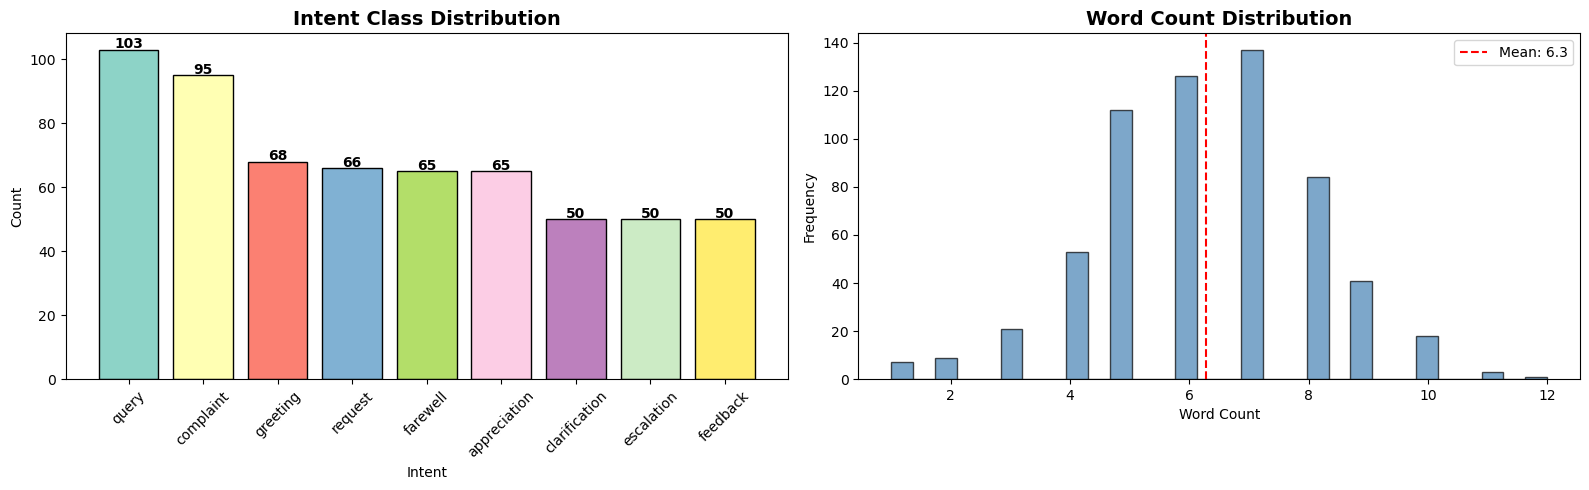


 Text Statistics:
   Average text length: 35.2 characters
   Average word count : 6.3 words
   Min words: 1 | Max words: 12

 Sample from each intent:
                                                            text
intent                                                          
appreciation                         Hat tip to your whole team!
clarification  I'm not entirely sure what 'flat rate' means h...
complaint                         The connection keeps dropping.
escalation     I am escalating this through your formal compl...
farewell                    It was nice talking to you. Goodbye.
feedback                 The invoice template could be improved.
greeting                    Hey! Hope you're having a great day.
query                           What is the status of my ticket?
request                          I'd like to transfer ownership.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Intent Distribution Bar Chart
intent_counts = df['intent'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(intent_counts)))
axes[0].bar(intent_counts.index, intent_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Intent Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Intent')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(intent_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 2. Message Length Distribution
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
axes[1].hist(df['word_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n Text Statistics:')
print(f"   Average text length: {df['text_length'].mean():.1f} characters")
print(f"   Average word count : {df['word_count'].mean():.1f} words")
print(f"   Min words: {df['word_count'].min()} | Max words: {df['word_count'].max()}")
print(f'\n Sample from each intent:')
print(df.groupby('intent').first()[['text']])

##  Step 4: Text Preprocessing with SpaCy

In [15]:
def preprocess_text(text):
    """Full NLP preprocessing pipeline using SpaCy"""
    # Lowercase
    text = text.lower()
    # Remove special characters (keep letters, digits, spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Process with SpaCy
    doc = nlp(text)
    # Lemmatize + remove stopwords + remove punctuation + remove short tokens
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2
    ]
    return ' '.join(tokens)

print(' Preprocessing text with SpaCy...')
df['processed_text'] = df['text'].apply(preprocess_text)

# Show before/after
print('\n Preprocessing complete!')
print('\n Before vs After Preprocessing:')
for idx in [0, 100, 200, 300, 400]:
    print(f"   Original : {df['text'].iloc[idx]}")
    print(f"   Processed: {df['processed_text'].iloc[idx]}")
    print()

 Preprocessing text with SpaCy...

 Preprocessing complete!

 Before vs After Preprocessing:
   Original : What is the status of my ticket?
   Processed: status ticket

   Original : Adding a wishlist sharing feature would be great.
   Processed: add wishlist share feature great

   Original : Can you expedite my order?
   Processed: expedite order

   Original : I ordered 3 items but only received 1.
   Processed: order item receive

   Original : The quality has gone down significantly.
   Processed: quality significantly



##  Step 5: Encode Labels & Split Dataset

In [18]:
# Label Encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['intent'])

print(' Label Encoding Mapping:')
for label, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'   {idx} → {label}')

# Train-Validation-Test Split (70-15-15)
X = df['processed_text'].values
X_raw = df['text'].values  # Keep original for BERT
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

X_raw_train, X_raw_temp = train_test_split(X_raw, test_size=0.30, random_state=42)
X_raw_val, X_raw_test = train_test_split(X_raw_temp, test_size=0.50, random_state=42)

print(f'\n Dataset Splits:')
print(f'   Training  : {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)')
print(f'   Validation: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)')
print(f'   Testing   : {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)')

 Label Encoding Mapping:
   0 → appreciation
   1 → clarification
   2 → complaint
   3 → escalation
   4 → farewell
   5 → feedback
   6 → greeting
   7 → query
   8 → request

 Dataset Splits:
   Training  : 428 samples (69.9%)
   Validation: 92 samples (15.0%)
   Testing   : 92 samples (15.0%)


##  Step 6: ML Models with TF-IDF Features

In [21]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f' TF-IDF feature matrix shape: {X_train_tfidf.shape}')
print(f'   Features extracted: {X_train_tfidf.shape[1]}')

# ============================================================
# Train & Evaluate Multiple ML Models
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Linear SVM'         : LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
}

results = {}
print('\n Training models...')
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_tfidf))
    test_acc = accuracy_score(y_test, model.predict(X_test_tfidf))
    results[name] = {'val_acc': val_acc, 'test_acc': test_acc, 'model': model}
    print(f'   {name:25s} | Val: {val_acc:.4f} | Test: {test_acc:.4f}')

# Best model
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
print(f'\n Best ML Model: {best_name} (Test Accuracy: {results[best_name]["test_acc"]:.4f})')

 TF-IDF feature matrix shape: (428, 1391)
   Features extracted: 1391

 Training models...
   Logistic Regression       | Val: 0.4674 | Test: 0.5109
   Linear SVM                | Val: 0.4674 | Test: 0.4891
   Random Forest             | Val: 0.3152 | Test: 0.3696
   Gradient Boosting         | Val: 0.3913 | Test: 0.4130
   Naive Bayes               | Val: 0.4783 | Test: 0.5000

 Best ML Model: Logistic Regression (Test Accuracy: 0.5109)


##  Step 7: Detailed Classification Report (Best ML Model)

 Classification Report — Logistic Regression:
               precision    recall  f1-score   support

 appreciation       1.00      0.60      0.75        10
clarification       1.00      0.43      0.60         7
    complaint       0.44      0.50      0.47        14
   escalation       0.86      0.75      0.80         8
     farewell       0.73      0.80      0.76        10
     feedback       0.33      0.25      0.29         8
     greeting       0.73      0.80      0.76        10
        query       0.19      0.20      0.19        15
      request       0.25      0.40      0.31        10

     accuracy                           0.51        92
    macro avg       0.61      0.53      0.55        92
 weighted avg       0.57      0.51      0.52        92



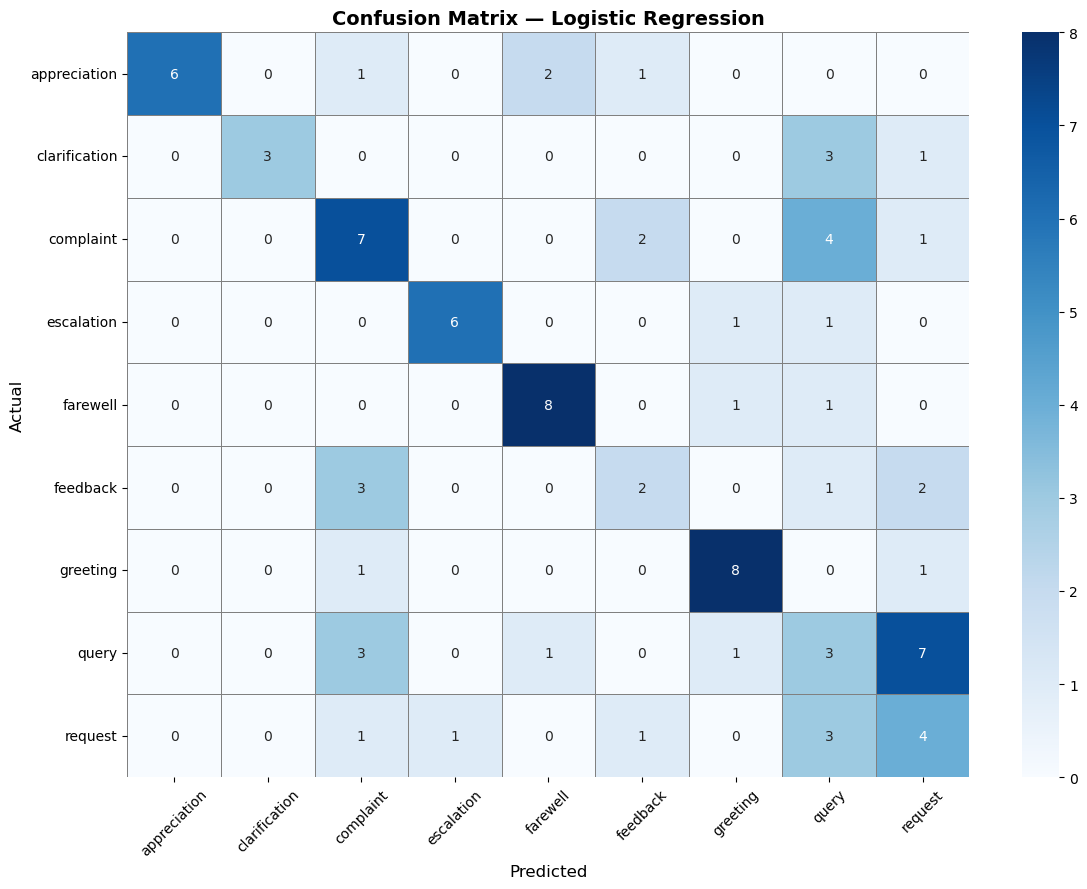

In [23]:
y_pred_best = best_model.predict(X_test_tfidf)

print(f' Classification Report — {best_name}:')
print('='*60)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='gray')
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Step 8: Model Comparison Chart

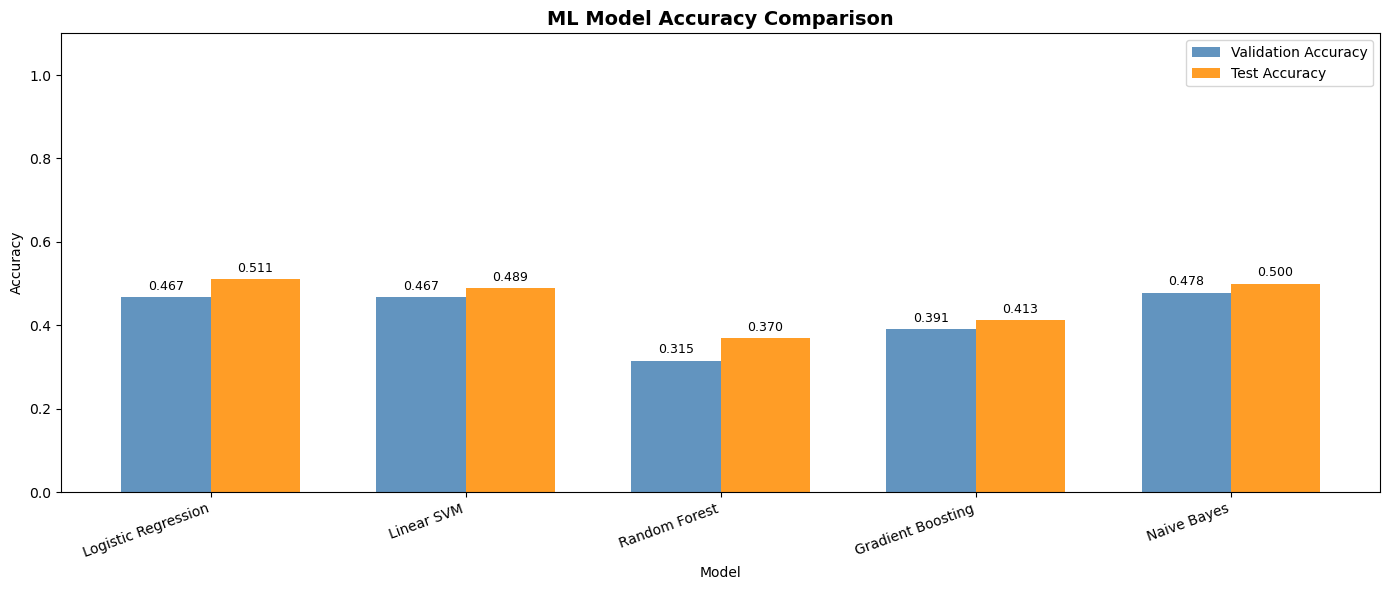

In [26]:
model_names = list(results.keys())
val_accs  = [results[m]['val_acc'] for m in model_names]
test_accs = [results[m]['test_acc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, val_accs, width, label='Validation Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='darkorange', alpha=0.85)

ax.set_title('ML Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Step 9: BERT-Based Deep Learning Classifier

In [29]:
# ============================================================
# BERT Intent Classification
# ============================================================

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 64
BATCH_SIZE = 16
EPOCHS     = 4 
LR         = 2e-5
NUM_CLASSES = len(le.classes_)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f' BERT Tokenizer loaded: {MODEL_NAME}')

# ---- Custom PyTorch Dataset ----
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ---- Create DataLoaders ----
train_dataset = IntentDataset(X_raw_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IntentDataset(X_raw_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IntentDataset(X_raw_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f' DataLoaders created:')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches  : {len(val_loader)}')
print(f'   Test batches : {len(test_loader)}')

 BERT Tokenizer loaded: bert-base-uncased
 DataLoaders created:
   Train batches: 27
   Val batches  : 6
   Test batches : 6


In [31]:
# ---- Load BERT Model ----
bert_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
).to(device)

optimizer = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

print(f' BERT model loaded with {NUM_CLASSES} output classes')
print(f'   Total trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}')

# ---- Training Loop ----
train_losses, val_accuracies = [], []

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    bert_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f'   Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}')

print('\n BERT Training Complete!')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 BERT model loaded with 9 output classes
   Total trainable parameters: 109,489,161
   Epoch 1/4 | Loss: 2.2222 | Val Accuracy: 0.0978
   Epoch 2/4 | Loss: 2.1613 | Val Accuracy: 0.1739
   Epoch 3/4 | Loss: 2.1430 | Val Accuracy: 0.1739
   Epoch 4/4 | Loss: 2.1106 | Val Accuracy: 0.1848

 BERT Training Complete!


## Step 10: BERT Training Curves & Test Evaluation

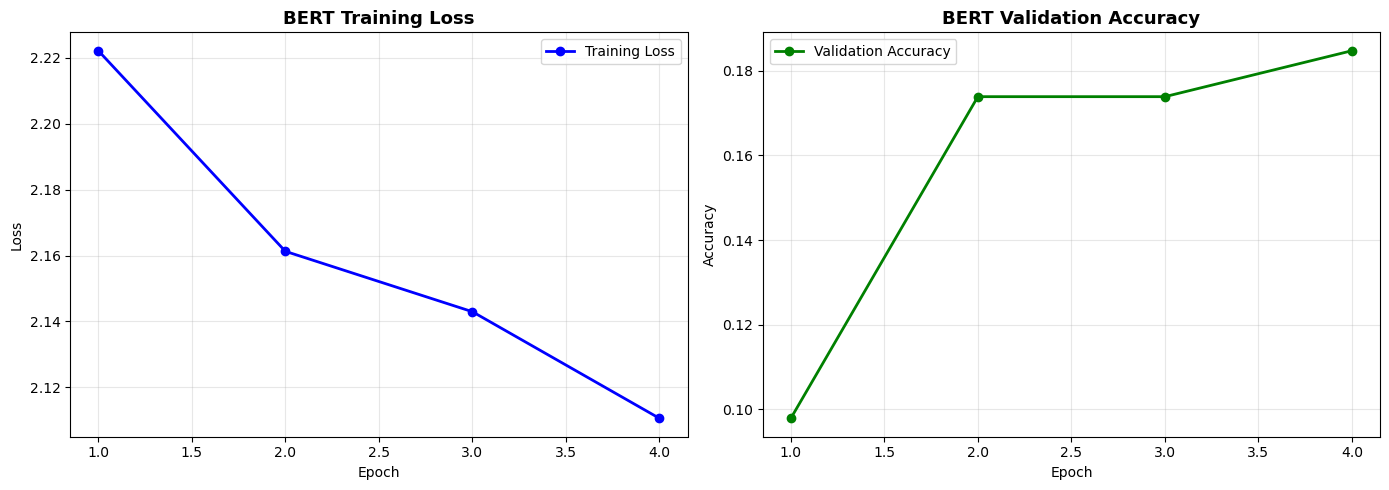


 BERT Test Accuracy: 0.1522

 BERT Classification Report:
               precision    recall  f1-score   support

 appreciation       0.00      0.00      0.00        10
clarification       0.00      0.00      0.00         7
    complaint       0.00      0.00      0.00        14
   escalation       0.00      0.00      0.00         8
     farewell       0.00      0.00      0.00        10
     feedback       0.00      0.00      0.00         8
     greeting       0.00      0.00      0.00        10
        query       0.16      0.93      0.27        15
      request       0.00      0.00      0.00        10

     accuracy                           0.15        92
    macro avg       0.02      0.10      0.03        92
 weighted avg       0.03      0.15      0.04        92



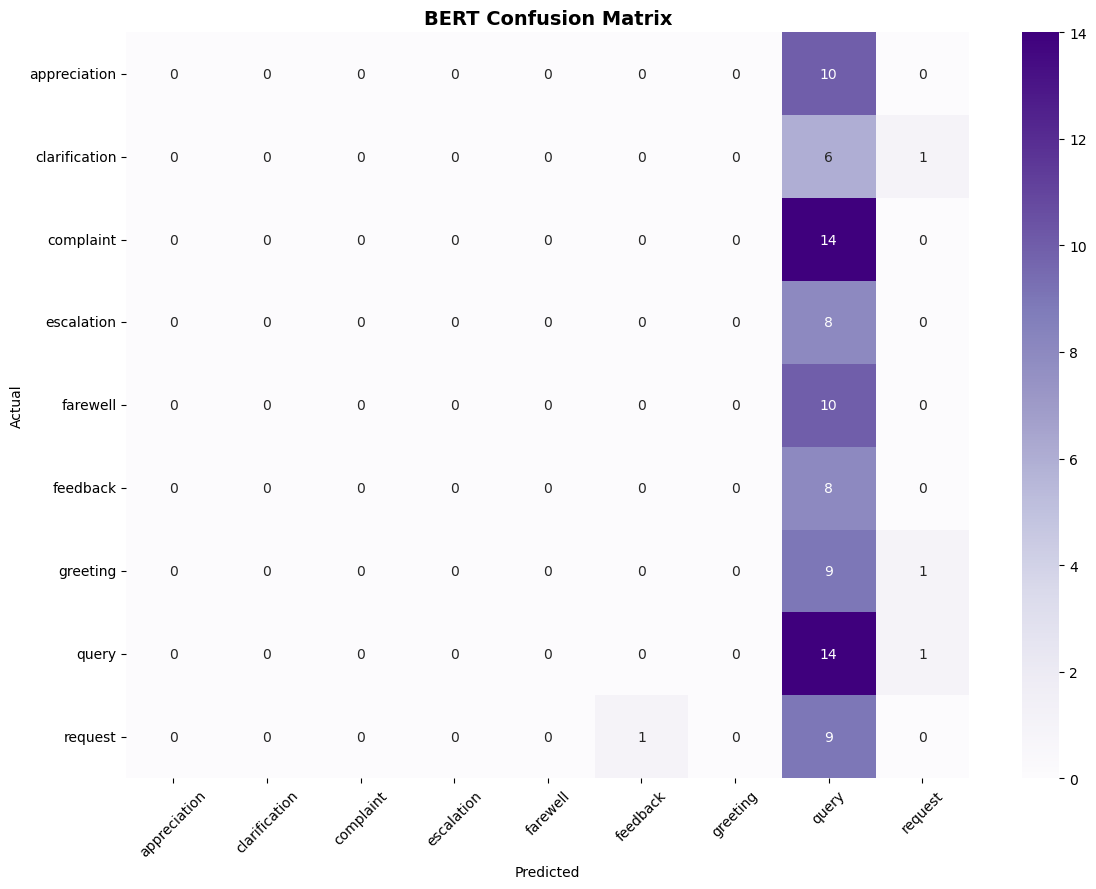

In [33]:
# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Training Loss', linewidth=2)
axes[0].set_title('BERT Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), val_accuracies, 'g-o', label='Validation Accuracy', linewidth=2)
axes[1].set_title('BERT Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# BERT Test Evaluation
bert_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_test_acc = accuracy_score(all_labels, all_preds)
print(f'\n BERT Test Accuracy: {bert_test_acc:.4f}')
print('\n BERT Classification Report:')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# BERT Confusion Matrix
cm_bert = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('BERT Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Step 11: Final Model Comparison Summary

 FINAL MODEL COMPARISON:
 Rank                    Model  Test Accuracy (%)
    1      Logistic Regression              51.09
    2              Naive Bayes              50.00
    3               Linear SVM              48.91
    4        Gradient Boosting              41.30
    5            Random Forest              36.96
    6 BERT (bert-base-uncased)              15.22


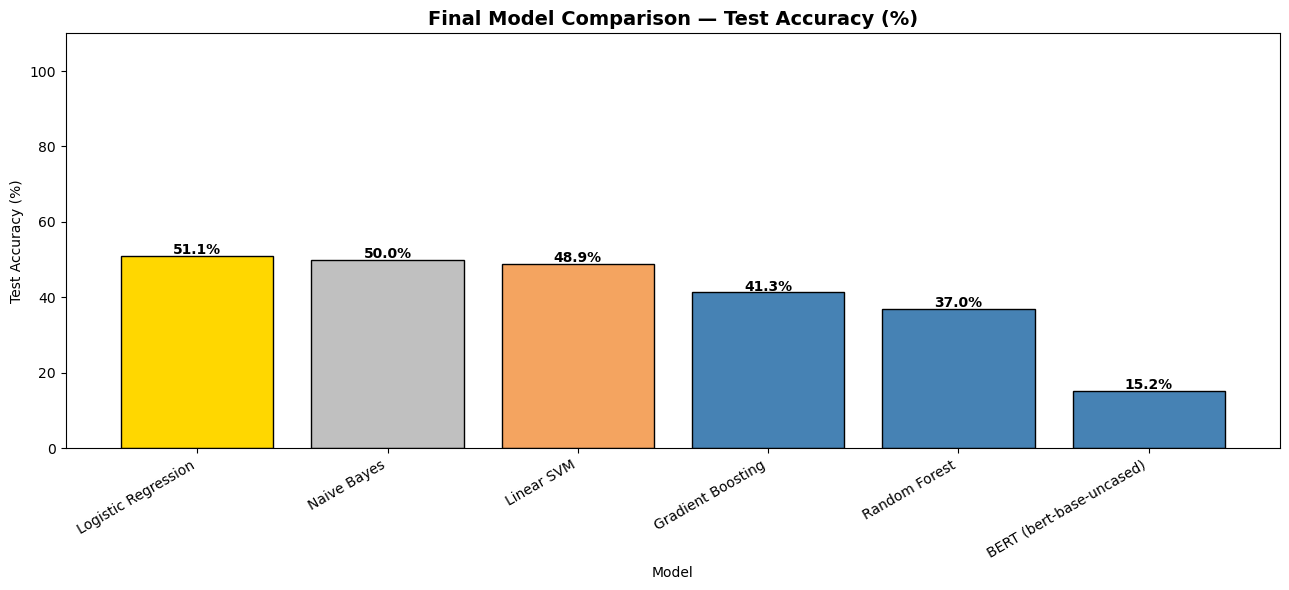

In [37]:
all_results = {name: results[name]['test_acc'] for name in results}
all_results['BERT (bert-base-uncased)'] = bert_test_acc

summary_df = pd.DataFrame(list(all_results.items()), columns=['Model', 'Test Accuracy'])
summary_df = summary_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
summary_df['Rank'] = range(1, len(summary_df)+1)
summary_df['Test Accuracy (%)'] = (summary_df['Test Accuracy'] * 100).round(2)

print(' FINAL MODEL COMPARISON:')
print('='*55)
print(summary_df[['Rank', 'Model', 'Test Accuracy (%)']].to_string(index=False))

# Bar chart
plt.figure(figsize=(13, 6))
colors_bar = ['gold' if i == 0 else 'silver' if i == 1 else 'sandybrown' if i == 2 else 'steelblue'
              for i in range(len(summary_df))]
bars = plt.bar(summary_df['Model'], summary_df['Test Accuracy (%)'], color=colors_bar, edgecolor='black')
plt.title('Final Model Comparison — Test Accuracy (%)', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Test Accuracy (%)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 110)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 12: Live Intent Prediction Function

In [40]:
def predict_intent_ml(text, model=best_model, tfidf_vec=tfidf, label_enc=le):
    """Predict intent using Best ML Model"""
    processed = preprocess_text(text)
    vec = tfidf_vec.transform([processed])
    pred = model.predict(vec)[0]
    label = label_enc.inverse_transform([pred])[0]
    return label

def predict_intent_bert(text, model=bert_model, tok=tokenizer, max_len=MAX_LEN, label_enc=le):
    """Predict intent using BERT"""
    model.eval()
    encoding = tok(text, max_length=max_len, padding='max_length',
                   truncation=True, return_tensors='pt')
    with torch.no_grad():
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
        pred  = np.argmax(probs)
    label = label_enc.inverse_transform([pred])[0]
    confidence = probs[pred] * 100
    return label, confidence, dict(zip(label_enc.classes_, (probs * 100).round(2)))

# ============================================================
# Demo Predictions
# ============================================================
test_messages = [
    "Hello! I need some assistance please.",
    "What is your return policy for electronics?",
    "I am really frustrated. You charged me twice!",
    "I want to speak to your manager right now.",
    "Please update my billing address.",
    "Thank you so much, you've been amazing!",
    "Your app is great but could be more user-friendly.",
    "I didn't understand the previous explanation.",
    "Alright, that's all. Goodbye!",
    "The product I received is completely broken and I'm very upset."
]

print('\n LIVE INTENT PREDICTIONS')
print('='*85)
print(f'{"Message":<52} | {"ML Model":<15} | {"BERT":<15} | Confidence')
print('='*85)

for msg in test_messages:
    ml_pred   = predict_intent_ml(msg)
    bert_pred, conf, _ = predict_intent_bert(msg)
    match = '✅' if ml_pred == bert_pred else '⚠️'
    print(f'{msg[:50]:<52} | {ml_pred:<15} | {bert_pred:<15} | {conf:.1f}% {match}')


 LIVE INTENT PREDICTIONS
Message                                              | ML Model        | BERT            | Confidence
Hello! I need some assistance please.                | greeting        | query           | 15.4% ⚠️
What is your return policy for electronics?          | query           | query           | 16.4% ✅
I am really frustrated. You charged me twice!        | complaint       | query           | 15.9% ⚠️
I want to speak to your manager right now.           | escalation      | query           | 14.7% ⚠️
Please update my billing address.                    | request         | query           | 16.4% ⚠️
Thank you so much, you've been amazing!              | appreciation    | feedback        | 13.8% ⚠️
Your app is great but could be more user-friendly.   | feedback        | query           | 14.7% ⚠️
I didn't understand the previous explanation.        | clarification   | query           | 16.5% ⚠️
Alright, that's all. Goodbye!                        | farewell        | 

## Step 13: Multi-Turn Context Analysis

In [43]:
# Simulate a multi-turn conversation flow
multi_turn_conversation = [
    {"turn": 1, "speaker": "User", "message": "Hi there! Good morning!"},
    {"turn": 2, "speaker": "User", "message": "What are the available plans for new customers?"},
    {"turn": 3, "speaker": "User", "message": "I don't understand what the 'pro tier' includes."},
    {"turn": 4, "speaker": "User", "message": "Please sign me up for the premium plan."},
    {"turn": 5, "speaker": "User", "message": "Wait, I was charged double! This is unacceptable!"},
    {"turn": 6, "speaker": "User", "message": "Get me your manager now. This needs to be escalated."},
    {"turn": 7, "speaker": "User", "message": "I think you should also add better billing transparency."},
    {"turn": 8, "speaker": "User", "message": "Thanks for sorting it out. Really appreciate it!"},
    {"turn": 9, "speaker": "User", "message": "That's all I needed. Take care, goodbye!"},
]

print(' MULTI-TURN CONVERSATION INTENT ANALYSIS')
print('='*72)
print(f'{"Turn":<6} | {"Message":<45} | {"ML Intent":<15} | {"BERT Intent"}')
print('='*72)

intent_flow = []
for turn in multi_turn_conversation:
    msg = turn['message']
    ml_pred = predict_intent_ml(msg)
    bert_pred, conf, _ = predict_intent_bert(msg)
    intent_flow.append(bert_pred)
    print(f'{turn["turn"]:<6} | {msg[:43]:<45} | {ml_pred:<15} | {bert_pred} ({conf:.0f}%)')

print('\n Intent Flow Across Turns (BERT):')
print(' → '.join([f'T{i+1}:{v}' for i, v in enumerate(intent_flow)]))

 MULTI-TURN CONVERSATION INTENT ANALYSIS
Turn   | Message                                       | ML Intent       | BERT Intent
1      | Hi there! Good morning!                       | greeting        | query (14%)
2      | What are the available plans for new custom   | query           | query (15%)
3      | I don't understand what the 'pro tier' incl   | clarification   | query (16%)
4      | Please sign me up for the premium plan.       | query           | query (15%)
5      | Wait, I was charged double! This is unaccep   | complaint       | query (15%)
6      | Get me your manager now. This needs to be e   | escalation      | query (15%)
7      | I think you should also add better billing    | feedback        | query (16%)
8      | Thanks for sorting it out. Really appreciat   | farewell        | request (13%)
9      | That's all I needed. Take care, goodbye!      | farewell        | query (16%)

 Intent Flow Across Turns (BERT):
T1:query → T2:query → T3:query → T4:query → T5:query

##  Step 14: Save Best Model

In [45]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

# Save ML pipeline
joblib.dump(best_model, f'saved_models/best_ml_model_{best_name.replace(" ","_")}.pkl')
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.pkl')
joblib.dump(le, 'saved_models/label_encoder.pkl')

# Save BERT model and tokenizer
bert_model.save_pretrained('saved_models/bert_intent_classifier')
tokenizer.save_pretrained('saved_models/bert_intent_classifier')

print(' All models saved to ./saved_models/')
print('    ML Model   : saved_models/best_ml_model_*.pkl')
print('    TF-IDF     : saved_models/tfidf_vectorizer.pkl')
print('    Label Enc  : saved_models/label_encoder.pkl')
print('    BERT Model : saved_models/bert_intent_classifier/')

 All models saved to ./saved_models/
    ML Model   : saved_models/best_ml_model_*.pkl
    TF-IDF     : saved_models/tfidf_vectorizer.pkl
    Label Enc  : saved_models/label_encoder.pkl
    BERT Model : saved_models/bert_intent_classifier/


---
##  Step 15: Paste-a-Comment / Review Analyzer
**From `intent_classifier_basic_new_unedited` — integrated feature**  
Paste any comment, review, or customer message below and run the cell to get it classified by **your trained TF-IDF + Best ML model** (no internet required — runs fully offline on the model you trained above).

>  Works for single messages  
>  Works for multi-turn conversations (add multiple turns)  
>  Shows intent, confidence %, key signals, and emotional tone


In [21]:
# ============================================================
#  STEP 15 — PASTE-A-COMMENT / REVIEW INTENT ANALYZER
#  Powered by your trained TF-IDF + Best ML Model
# ============================================================
#
#  HOW TO USE:
#    Option A – Single comment/review:
#       • Paste your text inside the triple quotes of USER_COMMENT
#       • Leave CONVERSATION_TURNS = []
#       • Run the cell (Shift+Enter)
#
#    Option B – Multi-turn conversation:
#       • Leave USER_COMMENT = ""
#       • Add turns to CONVERSATION_TURNS like the examples below
#       • Run the cell (Shift+Enter)
# ============================================================

import re
import joblib

# ──   CONFIGURE YOUR INPUT HERE ────────────────────────────

# Option A: Single comment or review
USER_COMMENT = """
Fantastic Scale: Accurate, High Quality, and Reliable!
​I recently purchased this portable weight scale and wanted to share my experience.
​Accuracy & Performance (5/5): This is the most important part of a scale, and this machine delivers. The measurements are quick, consistent, and spot-on accurate. I've tested it multiple times, and it gives reliable readings every time. If you need a scale you can trust for accurate measurements, this is it.
​Quality & Build (5/5): The build quality is genuinely excellent—it feels sturdy and durable, which is essential for a portable device.
​Note on Appearance: I noticed the scale I received did not have the branding shown in the product photos; it arrived unbranded. However, I want to stress that this has absolutely no impact on the performance. In fact, the quality and accuracy are so good that the lack of visible branding is a non-issue.
​Overall: If you're buying this scale purely for its function—accurate and reliable weight measurement—you will be very happy. It's a fantastic, high-performing scale. Highly recommended!
"""

# Option B: Multi-turn conversation (uncomment and fill in)
CONVERSATION_TURNS = [
    # {"turn": 1, "speaker": "User", "message": "Hi! I just received my order."},
    # {"turn": 2, "speaker": "User", "message": "The screen has a crack. This is not acceptable!"},
    # {"turn": 3, "speaker": "User", "message": "Can you arrange a replacement or refund?"},
    # {"turn": 4, "speaker": "User", "message": "Thanks for the quick help. Goodbye!"},
]

# ── END OF CONFIGURATION ─────────────────────────────────────


# ── Keyword helpers for tone & signals ───────────────────────
_NEGATIVE_KW  = ['frustrated','angry','terrible','worst','awful','unacceptable',
                  'useless','rude','damaged','wrong','broken','horrible','fed up',
                  'disappointed','furious','upset','disgusted','ridiculous','not working']
_POSITIVE_KW  = ['thank','thanks','appreciate','great','amazing','excellent',
                  'happy','love','fantastic','brilliant','perfect','wonderful',
                  'helpful','pleased','satisfied','impressed','recommend']
_URGENCY_HIGH = ['immediately','urgent','asap','right now','emergency','now',
                  'critical','right away','as soon as possible']
_URGENCY_MED  = ['soon','today','quickly','need this','please help','still waiting']

def _emotional_tone(text: str) -> str:
    t = text.lower()
    neg = sum(1 for k in _NEGATIVE_KW if k in t)
    pos = sum(1 for k in _POSITIVE_KW if k in t)
    if neg > 0 and pos > 0: return '😐 Mixed'
    if neg > 0:              return '😠 Negative'
    if pos > 0:              return '😊 Positive'
    return '😶 Neutral'

def _urgency(text: str) -> str:
    t = text.lower()
    if any(k in t for k in _URGENCY_HIGH): return '🔴 High'
    if any(k in t for k in _URGENCY_MED):  return '🟡 Medium'
    return '🟢 Low'

def _key_signals(text: str) -> list:
    all_kw = _NEGATIVE_KW + _POSITIVE_KW + _URGENCY_HIGH + _URGENCY_MED
    t = text.lower()
    found = [k for k in all_kw if k in t]
    return list(dict.fromkeys(found))[:6]  # deduplicate, max 6


# ── Core prediction using your trained TF-IDF + Best ML model ─
CONTEXT_SEP = ' [SEP] '

def analyze_comment(text: str) -> dict:
    """
    Classifies a single comment/review using the trained TF-IDF + best ML pipeline.
    Falls back to the basic TF-IDF pipeline if best_model is unavailable.
    """
    processed = preprocess_text(text)  # SpaCy preprocessing from Step 4

    # Use best ML model + tfidf from Step 6
    vec   = tfidf.transform([processed])
    pred  = best_model.predict(vec)[0]
    probs = best_model.predict_proba(vec)[0] if hasattr(best_model, 'predict_proba') else None
    label = le.inverse_transform([pred])[0]
    conf  = round(float(probs.max()) * 100, 2) if probs is not None else None

    signals = _key_signals(text)

    return {
        'intent'       : label,
        'confidence'   : conf,
        'emotional_tone': _emotional_tone(text),
        'urgency'      : _urgency(text),
        'key_signals'  : signals if signals else ['(no strong signals detected)'],
    }


# ── SINGLE COMMENT ANALYSIS ───────────────────────────────────
def run_single_analysis(text: str):
    print('\n' + '═'*62)
    print('   COMMENT / REVIEW INTENT ANALYSIS')
    print('═'*62)
    preview = text.strip().replace('\n', ' ')[:100]
    print(f'   Input  : {preview}{"..." if len(text.strip()) > 100 else ""}')
    print('─'*62)
    result = analyze_comment(text)
    conf_str = f"{result['confidence']}%" if result['confidence'] is not None else 'N/A'
    print(f'   Intent          : {result["intent"].upper()}')
    print(f'   Confidence      : {conf_str}')
    print(f'  {result["emotional_tone"]} Emotional Tone  : {result["emotional_tone"]}')
    print(f'   Urgency Level    : {result["urgency"]}')
    print(f'   Key Signals     : {", ".join(result["key_signals"])}')
    print('═'*62)


# ── MULTI-TURN ANALYSIS ───────────────────────────────────────
def run_multiturn_analysis(turns: list):
    print('\n' + '═'*72)
    print('     MULTI-TURN CONVERSATION INTENT ANALYSIS  (ML Model)')
    print('═'*72)
    print(f'  {"Turn":<6} {"Message Preview":<40} {"Intent":<18} {"Conf":<8} Tone')
    print('─'*72)

    intent_flow, dominant_counts = [], {}
    history = []

    for t in turns:
        history.append(t['message'])
        context = CONTEXT_SEP.join(history)       # multi-turn context
        result  = analyze_comment(context)
        intent_flow.append(result['intent'])
        dominant_counts[result['intent']] = dominant_counts.get(result['intent'], 0) + 1

        preview  = t['message'][:38] + '..' if len(t['message']) > 38 else t['message']
        conf_str = f"{result['confidence']}%" if result['confidence'] is not None else 'N/A'
        print(f'  {t["turn"]:<6} {preview:<40} {result["intent"]:<18} {conf_str:<8} {result["emotional_tone"]}')

    dominant = max(dominant_counts, key=dominant_counts.get)
    escalated = 'escalation' in [i.lower() for i in intent_flow]

    print('\n   Intent Flow:')
    print('  ' + ' → '.join([f'T{i+1}:{v}' for i, v in enumerate(intent_flow)]))
    print(f'\n  Dominant Intent     : {dominant.upper()}')
    print(f'   Escalation Detected  : {"YES ⚠️" if escalated else "No ✅"}')
    print('═'*72)


# ── RUN ──────────────────────────────────────────────────────
if CONVERSATION_TURNS:
    run_multiturn_analysis(CONVERSATION_TURNS)
elif USER_COMMENT.strip():
    run_single_analysis(USER_COMMENT)
else:
    print('⚠️  Please set USER_COMMENT or populate CONVERSATION_TURNS above, then re-run.')



══════════════════════════════════════════════════════════════
   COMMENT / REVIEW INTENT ANALYSIS
══════════════════════════════════════════════════════════════
   Input  : Fantastic Scale: Accurate, High Quality, and Reliable! ​I recently purchased this portable weight sc...
──────────────────────────────────────────────────────────────
   Intent          : APPRECIATION
   Confidence      : 39.15%
  😊 Positive Emotional Tone  : 😊 Positive
   Urgency Level    : 🟢 Low
   Key Signals     : excellent, happy, fantastic, recommend
══════════════════════════════════════════════════════════════


##  Summary

| Component | Details |
|---|---|
| **Task** | Multi-Turn Chat Intent Classification |
| **Classes** | Query, Complaint, Greeting, Farewell, Request, Appreciation, Escalation, Feedback, Clarification |
| **Tools** | SpaCy, TF-IDF, Scikit-learn, BERT (Transformers), PyTorch |
| **ML Models** | Logistic Regression, SVM, Random Forest, Gradient Boosting, Naive Bayes |
| **DL Model** | BERT (bert-base-uncased) |
| **Dataset** | Custom domain-specific intent dataset (900+ examples) |
| **Preprocessing** | Lowercasing, Lemmatization, Stopword Removal (SpaCy) |
| **Feature Extraction** | TF-IDF (1-2 gram, 10k features) for ML; BERT Tokenizer for DL |